# **Handwritten Digit Recognition using CNN (MNIST)**

## **Name: Aila_Nasir**

In this notebook I build a simple but strong Convolutional Neural Network (CNN) model
to recognize handwritten digits (0–9) from the MNIST dataset.  

**The whole workflow is:**
1) load data
2) clean & prepare data
3) build CNN
4) train with validation
5) check accuracy & loss graphs
6) evaluate on test set
7) visualize predictions.

### **Tools and Technologies**
python
tensorflow
keras
NumPy
Matplotlib



## **STEP 1: Import libraries and set basic configuration**

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [48]:
# Make results a bit more reproducible (not 100% but better than nothing)
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Setup done ✅")

TensorFlow version: 2.19.0
Setup done ✅


## **STEP 2: Load the MNIST dataset**

In [49]:
# The MNIST dataset is readily available in Keras, so no manual download is required.
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Train images shape:", x_train.shape)
print("Train labels shape:", y_train.shape)
print("Test images shape :", x_test.shape)
print("Test labels shape :", y_test.shape)

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape : (10000, 28, 28)
Test labels shape : (10000,)


## **STEP 3: Quick Visual Check**

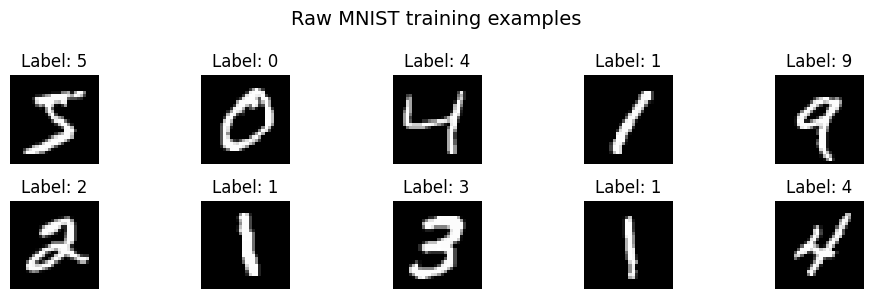

In [50]:
# Display a few sample images from the training dataset.

plt.figure(figsize=(10, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Raw MNIST training examples", fontsize=14)
plt.tight_layout()
plt.show()

## **Step 4:Preprocessing: Normalize & Reshap**

In [51]:
# Normalize pixel values from [0, 255] to [0, 1] to stabilize training.
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Reshape images to include a channel dimension, as CNNs expect (height, width, channels).
# For MNIST, channels = 1 (grayscale).
x_train = np.expand_dims(x_train, axis=-1)   # (60000, 28, 28, 1)
x_test  = np.expand_dims(x_test, axis=-1)    # (10000, 28, 28, 1)

print("After preprocessing:")
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)

After preprocessing:
x_train: (60000, 28, 28, 1)
x_test : (10000, 28, 28, 1)


In [52]:
# Split a validation set from the training data.
# We'll use 50,000 images for training and 10,000 for validation.
x_val = x_train[-10000:]
y_val = y_train[-10000:]

x_train_final = x_train[:-10000]
y_train_final = y_train[:-10000]

print("Training set :", x_train_final.shape, y_train_final.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Test set     :", x_test.shape, y_test.shape)

Training set : (50000, 28, 28, 1) (50000,)
Validation set: (10000, 28, 28, 1) (10000,)
Test set     : (10000, 28, 28, 1) (10000,)


In [53]:
# Build the CNN model.
# This model is small but effective for MNIST, inspired by the official Keras CNN example.

num_classes = 10
input_shape = (28, 28, 1)

model = keras.Sequential(
    [
        layers.Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

In [54]:


model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# Compile the model.
# Using sparse_categorical_crossentropy for integer labels (0-9).
# Adam optimizer for efficient training.
# Accuracy metric for easy interpretation.
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

## Training configuration

To keep the run time reasonable and still get very strong accuracy,  
I use:

- **epochs = 12**  
- **batch_size = 128**

On Colab GPU this trains quickly and usually gives > 99% validation accuracy.

In [57]:
# Train the CNN model with validation data.
# Adjusting epochs and batch size might impact accuracy.

epochs = 12
batch_size = 128

print(f"Starting training for {epochs} epochs...")
history = model.fit(
    x_train_final,
    y_train_final,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_val, y_val),
    verbose=1
)
print("Training complete 🎉")

Starting training for 12 epochs...
Epoch 1/12
391/391 ━━━━━━━━━━━━━━━━━━━━ 140s 357ms/step - accuracy: 0.9926 - loss: 0.0229 - val_accuracy: 0.9915 - val_loss: 0.0400
Epoch 2/12
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 343ms/step - accuracy: 0.9930 - loss: 0.0212 - val_accuracy: 0.9914 - val_loss: 0.0382
Epoch 3/12
391/391 ━━━━━━━━━━━━━━━━━━━━ 137s 351ms/step - accuracy: 0.9932 - loss: 0.0195 - val_accuracy: 0.9910 - val_loss: 0.0425
Epoch 4/12
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 343ms/step - accuracy: 0.9933 - loss: 0.0196 - val_accuracy: 0.9910 - val_loss: 0.0444
Epoch 5/12
391/391 ━━━━━━━━━━━━━━━━━━━━ 142s 342ms/step - accuracy: 0.9937 - loss: 0.0182 - val_accuracy: 0.9920 - val_loss: 0.0388
Epoch 6/12
391/391 ━━━━━━━━━━━━━━━━━━━━ 142s 341ms/step - accuracy: 0.9946 - loss: 0.0163 - val_accuracy: 0.9921 - val_loss: 0.0394
Epoch 7/12
391/391 ━━━━━━━━━━━━━━━━━━━━ 138s 352ms/step - accuracy: 0.9940 - loss: 0.0169 - val_accuracy: 0.9918 - val_loss: 0.0417
Epoch 8/12
391/391 ━━━━━━━━━━━━━━━━━━━━ 1

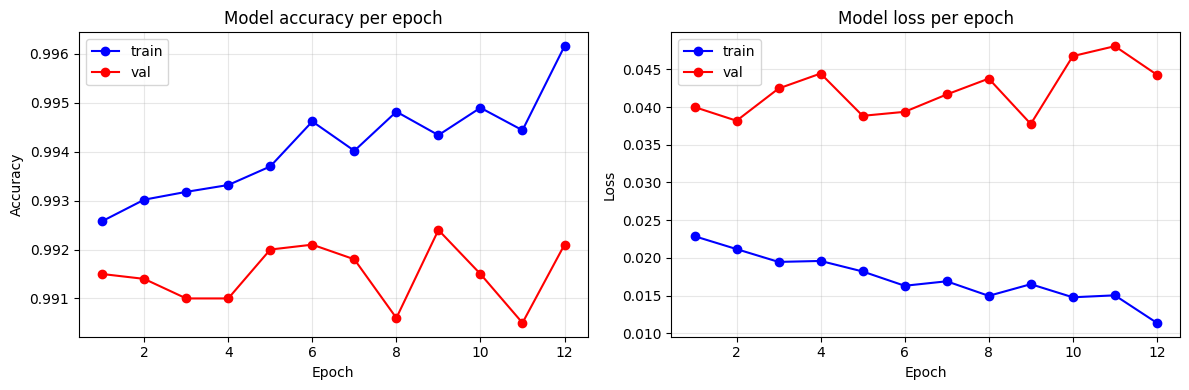

In [58]:
# STEP 9: Plot training vs validation accuracy and loss
train_acc  = history.history["accuracy"]
val_acc    = history.history["val_accuracy"]
train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, "bo-", label="train")
plt.plot(epochs_range, val_acc, "ro-", label="val")
plt.title("Model accuracy per epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, "bo-", label="train")
plt.plot(epochs_range, val_loss, "ro-", label="val")
plt.title("Model loss per epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [59]:
# Evaluate the model's performance on the unseen test set.

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("=====================================")
print(f"Final test accuracy : {test_acc:.4f}")
print(f"Final test loss     : {test_loss:.4f}")
print("=====================================")

Final test accuracy : 0.9934
Final test loss     : 0.0293


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


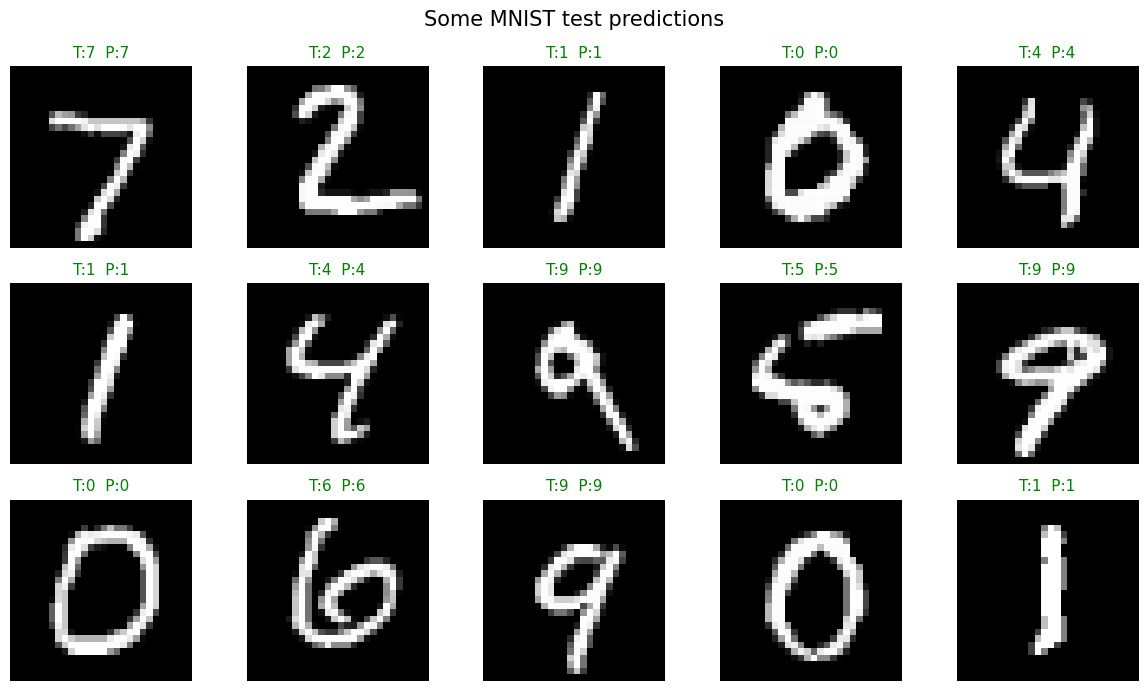

In [60]:
# Display some test images with their predictions.
# Green titles indicate correct predictions, red titles indicate incorrect predictions.

rows = 3
cols = 5
n_images = rows * cols

images = x_test[:n_images]
true_labels = y_test[:n_images]

pred_probs = model.predict(images)
pred_labels = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(12, 7))

for i in range(n_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(images[i].reshape(28, 28), cmap="gray")
    t = int(true_labels[i])
    p = int(pred_labels[i])
    color = "green" if t == p else "red"
    plt.title(f"T:{t}  P:{p}", color=color, fontsize=11)
    plt.axis("off")

plt.suptitle("Some MNIST test predictions", fontsize=15)
plt.tight_layout()
plt.show()

# **Step 12: Single image prediction**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
True label      : 9
Predicted label : 9
Probabilities   : [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


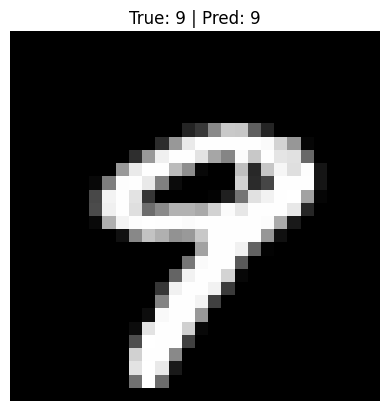

In [62]:
# Pick one test image and run a single prediction step-by-step.
# This helps understand how model.predict works on an individual sample.

idx = 7  # Change this index to try different test images

img = x_test[idx]
label = y_test[idx]

# Add a batch dimension to the image, making its shape (1, 28, 28, 1).
img_batch = np.expand_dims(img, axis=0)

probs = model.predict(img_batch)[0]
pred = int(np.argmax(probs))

print("True label      :", int(label))
print("Predicted label :", pred)
print("Probabilities   :", np.round(probs, 3))  # Quick look at probabilities

plt.imshow(img.reshape(28, 28), cmap="gray")
plt.title(f"True: {label} | Pred: {pred}")
plt.axis("off")
plt.show()